# Deflexión de la luz por un objeto masivo: métrica de Schwarzschild

**Relatividad General — Presentación 1, Tema 1: Tests de la Relatividad General**

Objetivo: calcular cuánto se desvía un rayo de luz que pasa cerca de un objeto masivo, usando la métrica de Schwarzschild, y comparar el resultado analítico con una integración numérica exacta y con las observaciones.

**Contenido**
1. La métrica de Schwarzschild y las geodésicas nulas
2. Ecuación de la órbita de un fotón
3. Solución perturbativa y ángulo de deflexión $\hat\alpha = 4GM/(c^2 b)$
4. Verificación simbólica (SymPy)
5. Integración numérica exacta y comparación
6. Trayectorias de la luz
7. El caso del Sol y verificación experimental
8. Más allá del régimen débil: esfera de fotones
9. Conclusiones y referencias

## 1. Métrica de Schwarzschild y geodésicas nulas

### 1.1 La métrica

Para el exterior de una masa $M$ esférica y estática, en coordenadas $(ct, r, \theta, \varphi)$ y con signatura $(-,+,+,+)$:

$$ds^2 = -f(r)\,c^2dt^2 + \frac{dr^2}{f(r)} + r^2\left(d\theta^2+\sin^2\theta\,d\varphi^2\right),\qquad f(r)\equiv 1-\frac{r_s}{r},\quad r_s\equiv\frac{2GM}{c^2}.$$

Lejos de la masa ($r\gg r_s$) $f\to1$ y recuperamos la métrica de Minkowski en coordenadas esféricas.

### 1.2 Trayectoria de un rayo de luz: geodésica nula

Un rayo de luz sigue una geodésica con $ds^2=0$. Parametrizamos la curva con un parámetro afín $\lambda$ y escribimos $\dot{x}^\mu = dx^\mu/d\lambda$. Las geodésicas son las extremales del lagrangiano

$$\mathcal{L}=\tfrac12\,g_{\mu\nu}\dot x^\mu\dot x^\nu = \tfrac12\left[-f\,c^2\dot t^{\,2}+\frac{\dot r^2}{f}+r^2\dot\theta^2+r^2\sin^2\theta\,\dot\varphi^2\right],$$

con la condición adicional (luz) $2\mathcal{L}=0$.

**Paso 1: el movimiento es plano.** La ecuación de Euler–Lagrange para $\theta$ es

$$\frac{d}{d\lambda}\left(r^2\dot\theta\right)=r^2\sin\theta\cos\theta\,\dot\varphi^2 .$$

Si en algún instante $\theta=\pi/2$ y $\dot\theta=0$, el lado derecho se anula ($\cos\theta=0$) y se mantiene $\dot\theta=0$: la órbita queda en el plano ecuatorial $\theta=\pi/2$. Como el problema es esféricamente simétrico, siempre podemos elegir los ejes para que esto ocurra. Con $\theta=\pi/2$ ($\sin\theta=1$, $\dot\theta=0$):

$$\mathcal{L}=\tfrac12\left[-f\,c^2\dot t^{\,2}+\frac{\dot r^2}{f}+r^2\dot\varphi^2\right].$$

**Paso 2: dos cantidades conservadas.** $\mathcal{L}$ no depende explícitamente de $t$ ni de $\varphi$ (variables cíclicas), así que sus momentos conjugados son constantes:

$$\frac{\partial\mathcal L}{\partial\dot t}=-f c^2\dot t\equiv -E \;\Rightarrow\; \boxed{E=f\,c^2\,\dot t}\qquad\qquad \frac{\partial\mathcal L}{\partial\dot\varphi}=r^2\dot\varphi\equiv L\;\Rightarrow\;\boxed{L=r^2\dot\varphi}$$

($E$ está asociada a la simetría bajo traslaciones temporales y $L$ a la simetría bajo rotaciones.)

**Paso 3: condición nula.** Imponemos $ds^2=0$, es decir $-f c^2\dot t^{\,2}+\dot r^2/f+r^2\dot\varphi^2=0$. Despejamos $\dot t$ y $\dot\varphi$ de las constantes de movimiento:

$$\dot t=\frac{E}{f c^2},\qquad \dot\varphi=\frac{L}{r^2}.$$

Sustituyendo:

$$-f c^2\frac{E^2}{f^2c^4}+\frac{\dot r^2}{f}+r^2\frac{L^2}{r^4}=0
\;\Longrightarrow\;
-\frac{E^2}{f c^2}+\frac{\dot r^2}{f}+\frac{L^2}{r^2}=0 .$$

Multiplicando por $f$ y despejando $\dot r^2$:

$$\boxed{\dot r^2=\frac{E^2}{c^2}-f(r)\,\frac{L^2}{r^2}=\frac{E^2}{c^2}-\left(1-\frac{r_s}{r}\right)\frac{L^2}{r^2}}\tag{1}$$

### 1.3 Significado del parámetro de impacto $b$

Lejos de la masa ($f\to1$) la ecuación (1) da $|\dot r|\to E/c$: el fotón se mueve en línea recta con "velocidad" $E/c$ en unidades del parámetro afín. Para una recta que pasa a distancia perpendicular $b$ del origen, el momento angular es $L=b\cdot(E/c)$ (distancia $\times$ velocidad). Por lo tanto

$$b\equiv\frac{c\,L}{E}$$

es el **parámetro de impacto**: la distancia a la que pasaría el rayo del centro si no hubiera deflexión.

## 2. Ecuación de la órbita $u(\varphi)$

Queremos la forma de la trayectoria, $r(\varphi)$, no su evolución en $\lambda$. Eliminamos $\lambda$ con la regla de la cadena:

$$\frac{dr}{d\varphi}=\frac{\dot r}{\dot\varphi}=\dot r\,\frac{r^2}{L}
\quad\Longrightarrow\quad
\left(\frac{dr}{d\varphi}\right)^2=\frac{r^4}{L^2}\,\dot r^2 .$$

**Paso 1.** Sustituimos (1):

$$\left(\frac{dr}{d\varphi}\right)^2=\frac{r^4}{L^2}\left[\frac{E^2}{c^2}-\left(1-\frac{r_s}{r}\right)\frac{L^2}{r^2}\right]
=\frac{E^2}{c^2L^2}\,r^4-\left(1-\frac{r_s}{r}\right)r^2 .$$

Como $\dfrac{E^2}{c^2L^2}=\dfrac{1}{b^2}$:

$$\left(\frac{dr}{d\varphi}\right)^2=\frac{r^4}{b^2}-r^2+r_s\,r .$$

**Paso 2: cambio de variable $u=1/r$.** Entonces $\dfrac{du}{d\varphi}=-\dfrac{1}{r^2}\dfrac{dr}{d\varphi}$, así que $\left(\dfrac{du}{d\varphi}\right)^2=\dfrac{1}{r^4}\left(\dfrac{dr}{d\varphi}\right)^2$. Dividiendo el resultado anterior por $r^4$:

$$\left(\frac{du}{d\varphi}\right)^2=\frac{1}{b^2}-\frac{1}{r^2}+\frac{r_s}{r^3}
\quad\Longrightarrow\quad
\boxed{\left(\frac{du}{d\varphi}\right)^2=\frac{1}{b^2}-u^2+r_s\,u^3}\tag{2}$$

**Paso 3: derivar respecto de $\varphi$.** Escribimos $u'=du/d\varphi$. Derivando ambos lados de (2):

$$2u'u''=\left(-2u+3r_s u^2\right)u' .$$

Dividiendo por $2u'$ (válido si $u'\neq0$):

$$\boxed{\frac{d^2u}{d\varphi^2}+u=\frac32\,r_s\,u^2=\frac{3GM}{c^2}\,u^2}\tag{3}$$

**Comprobación en el caso plano ($r_s=0$).** La ecuación (3) se reduce a $u''+u=0$, con solución $u_0=\sin\varphi/b$, es decir $r\sin\varphi=b$: la recta horizontal $y=b$. Además satisface (2): $u_0'^2=\cos^2\varphi/b^2=1/b^2-u_0^2$ ✓. El término $\tfrac32 r_s u^2$ es la corrección relativista; es pequeño frente a $u$ cuando $r_s\ll b$, porque $u\sim1/b$ implica $r_s u^2/u\sim r_s/b$.

## 3. Solución perturbativa y ángulo de deflexión

### 3.1 Desarrollo en el parámetro pequeño $\varepsilon=r_s/b$

Escribimos $u=u_0+u_1+\dots$, donde $u_0=\sin\varphi/b$ es la solución sin gravedad y $u_1=O(r_s)$ es la primera corrección. Sustituimos en (3):

$$\underbrace{u_0''+u_0}_{=0}+u_1''+u_1=\frac32 r_s\left(u_0+u_1\right)^2=\frac32 r_s u_0^2+\underbrace{3r_s u_0u_1+\dots}_{O(r_s^2)} .$$

Conservando solo el orden $r_s^1$:

$$u_1''+u_1=\frac32\,r_s\,\frac{\sin^2\varphi}{b^2}.$$

### 3.2 Resolver la ecuación para $u_1$

Usamos $\sin^2\varphi=\tfrac12(1-\cos2\varphi)$:

$$u_1''+u_1=\frac{3r_s}{4b^2}\left(1-\cos2\varphi\right).$$

Proponemos $u_1=A+B\cos2\varphi$. Entonces $u_1''=-4B\cos2\varphi$ y

$$u_1''+u_1=A+(1-4)B\cos2\varphi=A-3B\cos2\varphi .$$

Igualando coeficientes:

$$A=\frac{3r_s}{4b^2},\qquad -3B=-\frac{3r_s}{4b^2}\;\Rightarrow\;B=\frac{r_s}{4b^2}.$$

Por lo tanto $u_1=\dfrac{r_s}{4b^2}\left(3+\cos2\varphi\right)$. Con $\cos2\varphi=2\cos^2\varphi-1$ se tiene $3+\cos2\varphi=2\left(1+\cos^2\varphi\right)$, es decir

$$u_1=\frac{r_s}{2b^2}\left(1+\cos^2\varphi\right).$$

**Soluciones homogéneas.** A $u_1$ se le podría sumar $C_1\cos\varphi+C_2\sin\varphi$. El término en $\sin\varphi$ solo redefine $b$ (y con la definición $b=cL/E$ se verifica a este orden que $C_2=0$, ver abajo), y el término en $\cos\varphi$ es antisimétrico respecto de $\varphi=\pi/2$; elegimos el eje $x$ de modo que la órbita sea simétrica respecto del punto de máximo acercamiento ($\varphi=\pi/2$), lo que impone $C_1=0$. La solución a primer orden es

$$\boxed{u(\varphi)=\frac{\sin\varphi}{b}+\frac{r_s}{2b^2}\left(1+\cos^2\varphi\right)}\tag{4}$$

*Chequeo de $C_2=0$:* donde $u=0$ (rayo en el infinito), la ecuación (2) exige $u'^2=1/b^2$. Con (4), $u'=\dfrac{\cos\varphi}{b}-\dfrac{r_s}{b^2}\cos\varphi\sin\varphi$, y cerca de $\varphi\approx0$ (donde $\sin\varphi=O(r_s/b)$) queda $u'=\dfrac1b+O(r_s^2)$ ✓.

### 3.3 Ángulo de deflexión

En el infinito $u=0$. En el caso plano esto ocurre en $\varphi=0$ y $\varphi=\pi$ (la recta barre un ángulo $\pi$). Con la corrección, los ceros se desplazan ligeramente. Por simetría respecto de $\varphi=\pi/2$ son $\varphi=-\delta$ y $\varphi=\pi+\delta$ con $\delta=O(r_s/b)$ pequeño. Resolvemos $u(\pi+\delta)=0$ con (4):

$$\frac{\sin(\pi+\delta)}{b}+\frac{r_s}{2b^2}\left[1+\cos^2(\pi+\delta)\right]=0 .$$

Como $\sin(\pi+\delta)=-\sin\delta\approx-\delta$ y $\cos^2(\pi+\delta)=\cos^2\delta\approx1-\delta^2\approx1$ (el error cometido es de orden $r_s^2$, que ya despreciamos):

$$-\frac{\delta}{b}+\frac{r_s}{2b^2}\cdot2=0\quad\Longrightarrow\quad\delta=\frac{r_s}{b}.$$

La dirección de propagación gira un ángulo igual al exceso del ángulo barrido sobre $\pi$:

$$\hat\alpha=\Delta\varphi-\pi=(\pi+2\delta)-\pi=2\delta=\frac{2r_s}{b}.$$

Con $r_s=2GM/c^2$:

$$\boxed{\hat\alpha=\frac{2r_s}{b}=\frac{4GM}{c^2\,b}}\tag{5}$$

### 3.4 Comparación con el cálculo newtoniano

Si tratamos la luz como una partícula de velocidad $c$ que sigue (aproximadamente) la recta $y=b$, $x=ct$, la fuerza transversal por unidad de masa es $\dfrac{GM\,b}{(b^2+c^2t^2)^{3/2}}$. El cambio de velocidad transversal es

$$\Delta v_\perp=\int_{-\infty}^{\infty}\frac{GM\,b\,dt}{(b^2+c^2t^2)^{3/2}}=\frac{GM}{cb}\int_{-\infty}^{\infty}\frac{ds}{(1+s^2)^{3/2}}=\frac{2GM}{cb}\qquad(s=ct/b),$$

y el ángulo es $\alpha_N=\Delta v_\perp/c=\dfrac{2GM}{c^2b}$. La relatividad general predice **el doble**: la mitad viene de la dilatación temporal ($g_{tt}$) y la otra mitad de la curvatura espacial ($g_{rr}$), que en el cálculo newtoniano no aparece.

## 4. Verificación simbólica con SymPy

Comprobamos que $u_1$ resuelve la ecuación perturbada y que el ángulo de salida da $\hat\alpha = 2r_s/b$.

In [1]:
import sympy as sp

phi, b, rs = sp.symbols('varphi b r_s', positive=True)

u0 = sp.sin(phi)/b
u1 = rs/(2*b**2) * (1 + sp.cos(phi)**2)

# u1'' + u1 - (3/2) rs u0^2 debe ser 0
residuo = sp.simplify(sp.diff(u1, phi, 2) + u1 - sp.Rational(3, 2)*rs*u0**2)
print("Residuo de la ecuación perturbada:", residuo)

# la solución u0+u1 satisface la integral primera (2) hasta O(rs^2)
e = sp.symbols('e')
uu = (u0 + e*u1)
res2 = sp.series((sp.diff(uu, phi)**2 - (1/b**2 - uu**2 + e*rs*uu**3)).simplify(), e, 0, 2).removeO()
print("Residuo de la ecuación (2) a primer orden en rs:", sp.simplify(res2))

# ángulo de salida: resolver u(pi + d) = 0 a primer orden en d
d = sp.symbols('delta')
u = u0 + u1
eq = sp.series(u.subs(phi, sp.pi + d), d, 0, 2).removeO()
delta_sol = sp.solve(eq, d)[0]
print("delta =", delta_sol, "  ->  alpha = 2*delta =", sp.simplify(2*delta_sol))

Residuo de la ecuación perturbada: 0


Residuo de la ecuación (2) a primer orden en rs: 0
delta = r_s/b   ->  alpha = 2*delta = 2*r_s/b


## 5. Integración numérica exacta

La solución perturbativa (4) solo vale para $r_s\ll b$. Para saber cuánto falla, calculamos la deflexión **exacta** a partir de la integral primera (2), sin aproximar.

### 5.1 De la ecuación (2) a una integral para $\Delta\varphi$

De (2), $\left(\dfrac{du}{d\varphi}\right)^2=P(u)$ con

$$P(u)\equiv\frac{1}{b^2}-u^2+r_s\,u^3 .$$

Entonces $\dfrac{du}{d\varphi}=\pm\sqrt{P(u)}$, o bien $d\varphi=\pm\dfrac{du}{\sqrt{P(u)}}$.

**Trayectoria de $u$.** El rayo llega desde el infinito ($u=0$), se acerca ($u$ crece), alcanza su máximo acercamiento y se aleja ($u$ decrece hasta $0$). En el punto de máximo acercamiento $r=r_0$ se tiene $u=u_0\equiv1/r_0$ y $du/d\varphi=0$, es decir $P(u_0)=0$. Por lo tanto:

- $u_0$ es **la menor raíz positiva** de $P(u)=0$ (la cúbica $r_su^3-u^2+b^{-2}=0$; entre $0$ y $u_0$ se cumple $P>0$, que es lo que permite que $u$ crezca desde $0$).
- La rama de ida ($u$ creciente, signo $+$) y la de vuelta ($u$ decreciente, signo $-$) aportan el mismo ángulo, por simetría respecto de $\varphi=\pi/2$.

El ángulo total barrido es entonces

$$\Delta\varphi=2\int_0^{u_0}\frac{du}{\sqrt{P(u)}}=2\int_0^{u_0}\frac{du}{\sqrt{b^{-2}-u^2+r_s u^3}},\qquad\boxed{\hat\alpha_{\rm exacto}=\Delta\varphi-\pi}$$

**Chequeo ($r_s=0$).** Aquí $u_0=1/b$ y $\Delta\varphi=2\int_0^{1/b}\dfrac{du}{\sqrt{b^{-2}-u^2}}=2\arcsin(bu)\Big|_0^{1/b}=2\cdot\dfrac\pi2=\pi$, así que $\hat\alpha=0$ ✓.

### 5.2 Tratamiento numérico de la singularidad en $u_0$

En $u=u_0$ el integrando diverge como $(u_0-u)^{-1/2}$ (singularidad integrable, pero que degrada una cuadratura ordinaria). Como $u_0$ es raíz de $P$, podemos factorizar $P(u)=(u_0-u)\,Q(u)$. Dividiendo $r_s u^3-u^2+b^{-2}$ entre $(u-u_0)$:

$$r_su^3-u^2+b^{-2}=(u-u_0)\left[r_s u^2+(r_su_0-1)\,u+(r_su_0-1)\,u_0\right],$$

donde el resto de la división es cero porque $P(u_0)=0$ implica $b^{-2}=u_0^2-r_su_0^3$ (la identidad se comprueba abajo con SymPy). Como $(u-u_0)=-(u_0-u)$:

$$P(u)=(u_0-u)\,Q(u),\qquad Q(u)=-\left[r_su^2+(r_su_0-1)\,u+(r_su_0-1)\,u_0\right].$$

Así el integrando es $\dfrac{1}{\sqrt{u_0-u}}\cdot\dfrac1{\sqrt{Q(u)}}$, con $1/\sqrt{Q}$ regular en $[0,u_0]$, y la integral se calcula con la opción `weight='alg'` de `scipy.integrate.quad`, que trata exactamente el factor $(u_0-u)^{-1/2}$.

Trabajamos en unidades $GM/c^2=1$ (así $r_s=2$ y las longitudes se miden en $GM/c^2$).

In [2]:
# Verificación simbólica de la factorización P(u) = (u0 - u) Q(u),
# usando que b^-2 = u0^2 - rs*u0^3  (porque P(u0) = 0)
import sympy as sp
u, u0s, rss = sp.symbols('u u_0 r_s', positive=True)
binv2 = u0s**2 - rss*u0s**3
P = binv2 - u**2 + rss*u**3
Q = -(rss*u**2 + (rss*u0s - 1)*u + (rss*u0s - 1)*u0s)
print("P - (u0-u)*Q =", sp.simplify(sp.expand(P - (u0s - u)*Q)))

P - (u0-u)*Q = 0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})

def alpha_exacto(b, M=1.0):
    # deflexión exacta (rad) para parámetro de impacto b, en unidades G=c=1
    rs = 2*M
    # 1) u0 = menor raíz positiva real de  rs u^3 - u^2 + 1/b^2 = 0
    raices = np.roots([rs, -1, 0, 1/b**2])
    u0 = min(r.real for r in raices if abs(r.imag) < 1e-12 and r.real > 0)
    # 2) Q(u) tal que P(u) = (u0 - u) Q(u)
    k = rs*u0 - 1
    Q = lambda u: -(rs*u**2 + k*u + k*u0)
    # 3) integral con peso algebraico (u0-u)^(-1/2)  ->  wvar=(alpha, beta)=(0, -1/2)
    integral, _ = quad(lambda u: 1/np.sqrt(Q(u)), 0, u0, weight='alg', wvar=(0, -0.5))
    return 2*integral - np.pi

alpha_1 = lambda b, M=1.0: 4*M/b   # primer orden

for b in [1e3, 1e2, 30, 10, 6]:
    ex, a1 = alpha_exacto(b), alpha_1(b)
    print(f"b = {b:7.1f} GM/c²   exacto = {ex:.6f} rad   4GM/c²b = {a1:.6f} rad   error relativo = {abs(ex-a1)/ex:.2%}")

b =  1000.0 GM/c²   exacto = 0.004012 rad   4GM/c²b = 0.004000 rad   error relativo = 0.29%
b =   100.0 GM/c²   exacto = 0.041223 rad   4GM/c²b = 0.040000 rad   error relativo = 2.97%
b =    30.0 GM/c²   exacto = 0.148248 rad   4GM/c²b = 0.133333 rad   error relativo = 10.06%
b =    10.0 GM/c²   exacto = 0.590396 rad   4GM/c²b = 0.400000 rad   error relativo = 32.25%
b =     6.0 GM/c²   exacto = 1.719388 rad   4GM/c²b = 0.666667 rad   error relativo = 61.23%


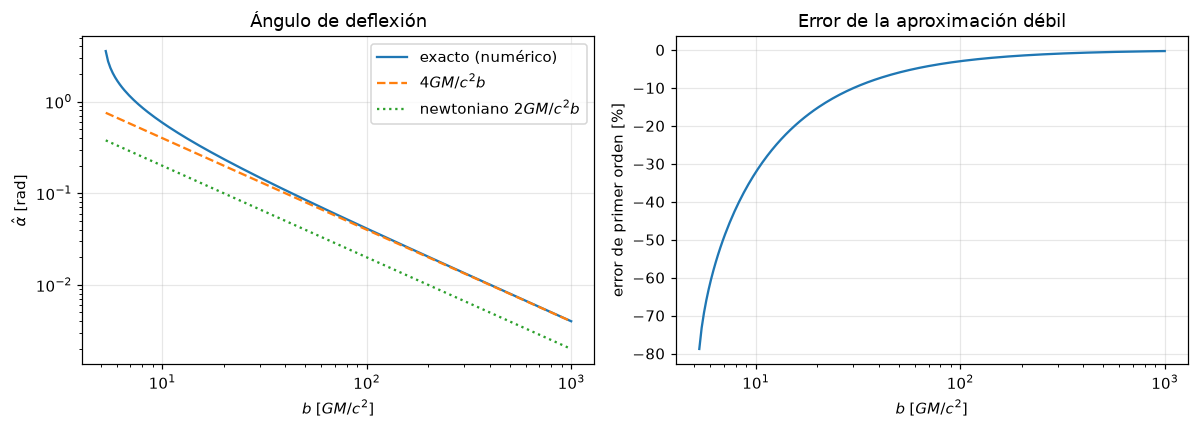

In [4]:
b_c = 3*np.sqrt(3)   # parámetro de impacto crítico (sección 8)
b_vals = np.logspace(np.log10(b_c*1.02), 3, 200)
ex = np.array([alpha_exacto(b) for b in b_vals])
a1 = alpha_1(b_vals)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog(b_vals, ex, label="exacto (numérico)")
ax[0].loglog(b_vals, a1, "--", label=r"$4GM/c^2b$")
ax[0].loglog(b_vals, a1/2, ":", label=r"newtoniano $2GM/c^2b$")
ax[0].set(xlabel=r"$b \;[GM/c^2]$", ylabel=r"$\hat\alpha$ [rad]", title="Ángulo de deflexión")
ax[0].legend()

ax[1].semilogx(b_vals, (a1-ex)/ex*100)
ax[1].set(xlabel=r"$b \;[GM/c^2]$", ylabel="error de primer orden [%]", title="Error de la aproximación débil")
plt.tight_layout(); plt.show()

La fórmula de primer orden coincide con la solución exacta para $b\gg GM/c^2$ (el error relativo decrece como $\sim 1/b$). Al acercarse $b$ a $b_c\approx5.2\,GM/c^2$ la deflexión diverge (sección 8).

### 5.3 Deducción del segundo orden: $\hat\alpha=\dfrac{4GM}{c^2b}+\dfrac{15\pi}{4}\left(\dfrac{GM}{c^2b}\right)^2$

Seguimos el método de la sección 3, un orden más. Sea $M\equiv GM/c^2$ (longitud), así $r_s=2M$ y la ecuación (3) es $u''+u=3Mu^2$.

**Paso 1: coordenada simétrica.** La ecuación es invariante bajo $\varphi\to\pi-\varphi$, y la órbita es simétrica respecto del punto de máximo acercamiento. Definimos $\psi=\varphi-\pi/2$ (así $\psi=0$ es el máximo acercamiento y la solución es par en $\psi$). Como $\sin\varphi=\cos\psi$, la solución de primer orden (4) queda

$$u=\frac{\cos\psi}{b}+\frac{M}{b^2}\left(1+\sin^2\psi\right)+u_2,\qquad u_2=O(M^2).$$

**Paso 2: ecuación para $u_2$.** Sustituimos en $u''+u=3Mu^2$ y conservamos el orden $M^2$ (los órdenes $M^0$ y $M^1$ ya se cancelan por construcción):

$$u_2''+u_2=3M\cdot2\,u_0u_1=6M\,\frac{\cos\psi}{b}\cdot\frac{M}{b^2}\left(1+\sin^2\psi\right)=\frac{6M^2}{b^3}\cos\psi\left(1+\sin^2\psi\right).$$

**Paso 3: descomponer la fuerza en armónicos.** Usamos $\sin^2\psi\cos\psi=\tfrac14\left(\cos\psi-\cos3\psi\right)$ (de $\cos3\psi=4\cos^3\psi-3\cos\psi$ y $\sin^2\psi\cos\psi=\cos\psi-\cos^3\psi$):

$$\cos\psi\left(1+\sin^2\psi\right)=\frac54\cos\psi-\frac14\cos3\psi
\;\Longrightarrow\;
u_2''+u_2=\frac{15M^2}{2b^3}\cos\psi-\frac{3M^2}{2b^3}\cos3\psi .$$

**Paso 4: resolver término a término.**

- *Término en $\cos3\psi$ (no resonante):* con $u=A\cos3\psi$, $u''+u=(1-9)A\cos3\psi=-8A\cos3\psi$. Igualando a $-\dfrac{3M^2}{2b^3}\cos3\psi$ se obtiene $A=\dfrac{3M^2}{16b^3}$.
- *Término en $\cos\psi$ (**resonante**, pues $\cos\psi$ es solución homogénea):* se propone $u=B\,\psi\sin\psi$. Entonces $u''=B\left(2\cos\psi-\psi\sin\psi\right)$ y $u''+u=2B\cos\psi$. Igualando a $\dfrac{15M^2}{2b^3}\cos\psi$ se obtiene $B=\dfrac{15M^2}{4b^3}$. Este es un término "secular" ($\propto\psi$) y es el que produce el coeficiente $15\pi/4$.

Por lo tanto

$$u_2=\frac{15M^2}{4b^3}\,\psi\sin\psi+\frac{3M^2}{16b^3}\cos3\psi+C\cos\psi .$$

La elección $\psi\sin\psi$ (y no $\varphi\cos\varphi$) es la que mantiene la solución par en $\psi$. La constante $C=O(M^2/b^3)$ (solución homogénea) solo reescala el término $\cos\psi/b$ en una cantidad relativa $O(M^2/b^2)$; como multiplica a $\cos\psi\approx-\delta$ en el punto de salida, afecta al ángulo solo a orden $M^3$ y no la necesitamos.

**Paso 5: ángulo de salida.** El rayo sale al infinito en $\psi=\pi/2+\delta$ con $u=0$. Desarrollamos cada término con $\delta$ pequeño:

$$\cos\psi=-\sin\delta\approx-\delta,\qquad \sin^2\psi=\cos^2\delta\approx1-\delta^2,\qquad \psi\sin\psi\approx\frac\pi2+\delta,\qquad\cos3\psi=\sin3\delta\approx3\delta.$$

Multiplicando $u(\psi)=0$ por $b$ y escribiendo $x\equiv M/b$:

$$-\delta+x\left(2-\delta^2\right)+\frac{15}{4}x^2\left(\frac\pi2+\delta\right)+\frac{9}{16}x^2\delta+\dots=0 .$$

Como $\delta=O(x)$, los términos $x\delta^2$, $x^2\delta$ son $O(x^3)$ y se descartan. Queda

$$\delta=2x+\frac{15\pi}{8}x^2+O(x^3).$$

**Paso 6: deflexión.** $\Delta\varphi=2\psi_\infty=\pi+2\delta$, luego

$$\hat\alpha=2\delta=4x+\frac{15\pi}{4}x^2=\frac{4GM}{c^2b}+\frac{15\pi}{4}\left(\frac{GM}{c^2b}\right)^2+O\!\left(\frac{M^3}{b^3}\right)\qquad\blacksquare$$

El primer término reproduce (5) y el segundo es la corrección buscada. Verificamos los pasos con SymPy y luego numéricamente.

In [5]:
# Verificación simbólica de la solución de segundo orden
psi, b, m, e = sp.symbols('psi b m e', positive=True)   # M = e*m  (e marca el orden)
M = e*m
u = (sp.cos(psi)/b + M/b**2*(1 + sp.sin(psi)**2)
     + M**2/b**3*(sp.Rational(15, 4)*psi*sp.sin(psi) + sp.Rational(3, 16)*sp.cos(3*psi)))

# 1) u'' + u - 3 M u^2 debe anularse hasta O(e^2)
res = sp.expand(sp.diff(u, psi, 2) + u - 3*M*u**2)
res_hasta_e2 = sum(sp.trigsimp(sp.expand_trig(res.coeff(e, k))) for k in range(3))
print("Residuo de la EDO hasta O(M^2):", sp.simplify(res_hasta_e2))

# 2) ángulo de salida: u(pi/2 + delta) = 0 con delta = d1 e + d2 e^2
d1, d2 = sp.symbols('d1 d2')
delta = d1*e + d2*e**2
expr = sp.series(sp.expand((b*u).subs(psi, sp.pi/2 + delta)), e, 0, 3).removeO()
sol = sp.solve([expr.coeff(e, 1), expr.coeff(e, 2)], [d1, d2], dict=True)[0]
alpha2 = sp.simplify(2*(sol[d1] + sol[d2]))   # alpha = 2*delta, con e -> 1
print("alpha =", sp.expand(alpha2.subs(m, sp.Symbol('M'))))

Residuo de la EDO hasta O(M^2): 0
alpha = 15*pi*M**2/(4*b**2) + 4*M/b


In [6]:
# Comprobación numérica con la integral exacta
b = 200.0
a2 = 4/b + 15*np.pi/4/b**2
print(f"exacto: {alpha_exacto(b):.8f}   1er orden: {4/b:.8f}   2º orden: {a2:.8f}")

exacto: 0.02029997   1er orden: 0.02000000   2º orden: 0.02029452


## 6. Trayectorias de la luz

Integramos directamente $u''+u=3Mu^2$ (con $G=c=1$, $M=1$) para varios parámetros de impacto. La condición inicial es $u(0)=0$, $u'(0)=1/b$ (rayo que llega desde $\varphi=0$, lejos de la masa) y se integra hasta que $u$ vuelve a cero. Comparamos con la línea recta (sin gravedad).

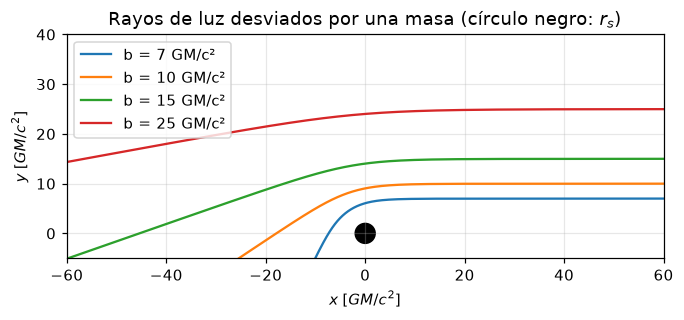

In [7]:
def trayectoria(b, M=1.0):
    f = lambda p, y: [y[1], -y[0] + 3*M*y[0]**2]
    ev = lambda p, y: y[0]
    ev.terminal, ev.direction = True, -1
    sol = solve_ivp(f, [0, 4*np.pi], [0, 1/b], events=ev, rtol=1e-11, atol=1e-13,
                    dense_output=True)
    p = np.linspace(0.02, sol.t[-1] - 0.02, 4000)
    u = sol.sol(p)[0]
    r = 1/u
    return r*np.cos(p), r*np.sin(p)

fig, ax = plt.subplots(figsize=(7, 5))
for b in [7, 10, 15, 25]:
    x, y = trayectoria(b)
    ax.plot(x, y, label=f"b = {b} GM/c²")
ax.add_patch(plt.Circle((0, 0), 2, color="k"))   # r_s = 2GM/c²
ax.set(xlim=(-60, 60), ylim=(-5, 40), aspect="equal", xlabel=r"$x\;[GM/c^2]$", ylabel=r"$y\;[GM/c^2]$",
       title="Rayos de luz desviados por una masa (círculo negro: $r_s$)")
ax.legend(); plt.show()

## 7. El Sol y las observaciones

Para un rayo que **roza** el limbo solar, $b=R_\odot$:

In [8]:
G, c = 6.67430e-11, 2.99792458e8
M_sun, R_sun = 1.98847e30, 6.957e8
rad2arcsec = 180/np.pi*3600

alpha_sol = 4*G*M_sun/(c**2*R_sun)
print(f"GM/c² (Sol)       = {G*M_sun/c**2:.1f} m")
print(f"r_s / R_sol       = {2*G*M_sun/c**2/R_sun:.2e}   (régimen de campo débil)")
print(f"Deflexión RG      = {alpha_sol:.3e} rad = {alpha_sol*rad2arcsec:.4f} segundos de arco")
print(f"Deflexión newton. = {alpha_sol/2*rad2arcsec:.4f} segundos de arco")

# Verificación con la integral exacta (unidades GM/c²)
b_sol = R_sun/(G*M_sun/c**2)
print(f"Deflexión exacta  = {alpha_exacto(b_sol)*rad2arcsec:.4f} segundos de arco")

GM/c² (Sol)       = 1476.7 m
r_s / R_sol       = 4.25e-06   (régimen de campo débil)
Deflexión RG      = 8.490e-06 rad = 1.7512 segundos de arco
Deflexión newton. = 0.8756 segundos de arco
Deflexión exacta  = 1.7513 segundos de arco


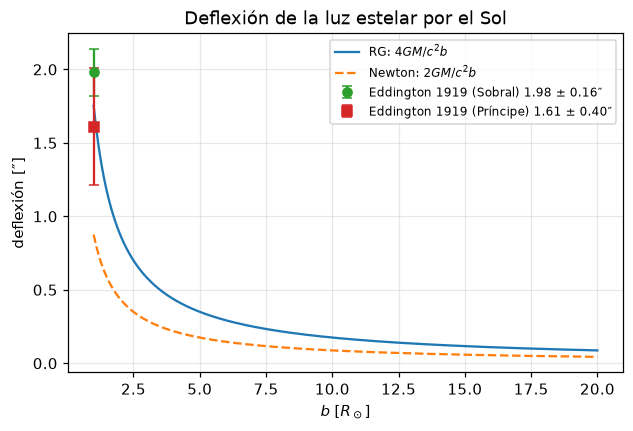

In [9]:
# Deflexión en función de la distancia al centro del Sol (en radios solares)
b_Rsun = np.linspace(1, 20, 200)
a = 4*G*M_sun/(c**2*b_Rsun*R_sun)*rad2arcsec

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(b_Rsun, a, label="RG: $4GM/c^2b$")
ax.plot(b_Rsun, a/2, "--", label="Newton: $2GM/c^2b$")
ax.errorbar([1.0], [1.98], yerr=[0.16], fmt="o", capsize=3, label="Eddington 1919 (Sobral) 1.98 ± 0.16″")
ax.errorbar([1.0], [1.61], yerr=[0.40], fmt="s", capsize=3, label="Eddington 1919 (Príncipe) 1.61 ± 0.40″")
ax.set(xlabel=r"$b\;[R_\odot]$", ylabel="deflexión [″]", title="Deflexión de la luz estelar por el Sol")
ax.legend(fontsize=8); plt.show()

### Verificación experimental

| Experimento | Resultado | Cociente con RG |
|---|---|---|
| Eddington, eclipse de 1919 (Sobral) | $1.98\pm0.16''$ | ≈ 1.13 |
| Eddington, eclipse de 1919 (Príncipe) | $1.61\pm0.40''$ | ≈ 0.92 |
| Interferometría radio (VLBI) | acuerdo a < 0.1 % | ≈ 1.000 |

Los datos de 1919 descartaron el valor newtoniano (0.87″) y favorecieron el de Einstein (1.75″). Las medidas modernas por radio (VLBI) confirman el factor 2 con gran precisión. Las cifras son valores de referencia de la literatura; conviene verificar la fuente primaria antes de exponer.

Parametrizado en el formalismo PPN, $\hat\alpha = \tfrac{1+\gamma}{2}\cdot\tfrac{4GM}{c^2b}$: la observación fija $\gamma = 1$ (RG) con gran precisión. El valor newtoniano correspondería a $\gamma=0$.

## 8. Más allá del campo débil: esfera de fotones

Para $b$ comparable a $r_s$, el rayo puede dar vueltas alrededor de la masa. En $r=3GM/c^2$ hay una órbita circular inestable (**esfera de fotones**). El parámetro de impacto crítico es

$$b_c = \frac{3\sqrt3\,GM}{c^2}\approx 5.196\,\frac{GM}{c^2}.$$

Para $b<b_c$ la luz es capturada; para $b\to b_c^+$ el ángulo de deflexión diverge logarítmicamente.

b crítico = 5.196152422706632 GM/c²
b = b_c(1+0.1):  alpha = 2.081 rad = 0.33 vueltas
b = b_c(1+0.01):  alpha = 4.230 rad = 0.67 vueltas
b = b_c(1+0.0001):  alpha = 8.810 rad = 1.40 vueltas
b = b_c(1+1e-06):  alpha = 13.415 rad = 2.14 vueltas


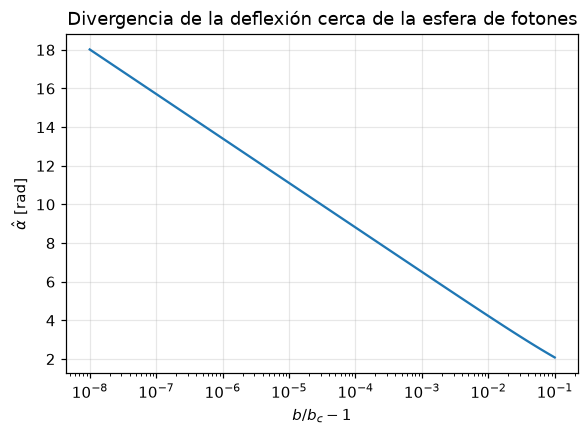

In [10]:
print("b crítico =", b_c, "GM/c²")
for eps in [1e-1, 1e-2, 1e-4, 1e-6]:
    bb = b_c*(1+eps)
    al = alpha_exacto(bb)
    print(f"b = b_c(1+{eps:g}):  alpha = {al:.3f} rad = {al/(2*np.pi):.2f} vueltas")

bs = b_c*(1 + np.logspace(-8, -1, 100))
al = np.array([alpha_exacto(x) for x in bs])
plt.figure(figsize=(6, 4))
plt.semilogx(bs/b_c - 1, al)
plt.xlabel(r"$b/b_c-1$"); plt.ylabel(r"$\hat\alpha$ [rad]")
plt.title("Divergencia de la deflexión cerca de la esfera de fotones"); plt.show()

## 9. Conclusiones

- La luz sigue geodésicas nulas; en Schwarzschild satisfacen $u''+u=3GMu^2/c^2$.
- A primer orden, la deflexión es $\hat\alpha = 4GM/(c^2b)$, **el doble** de la predicción newtoniana.
- Para el Sol, $\hat\alpha_\odot\approx1.75''$; las observaciones (eclipse de 1919 y, con mucha más precisión, VLBI) confirman la RG.
- La integral exacta muestra que la aproximación débil es excelente para $b\gg GM/c^2$ y que la deflexión diverge en $b_c=3\sqrt3\,GM/c^2$.

### Referencias
- Bert Janssen, *Teoría de la Relatividad General*, Universidad de Granada (2013).
- Sean Carroll, *Spacetime and Geometry*, Addison Wesley (2004).
- David Tong, *Lectures on General Relativity*, <http://www.damtp.cam.ac.uk/user/tong/gr.html>.
- F. W. Dyson, A. S. Eddington, C. Davidson, *Phil. Trans. R. Soc. A* **220**, 291 (1920).